In [10]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [11]:
DATA_DIR = Path("/home/jovyan/Desktop/IDX intern/california")
f = DATA_DIR / "california_sfr_202505_202605.csv"

print(f"Reading: {f.name}")

df = pd.read_csv(f, low_memory=False)
df["source_file"] = f.name
df["CloseDate"] = pd.to_datetime(df["CloseDate"])

print(f"\nTotal shape: {df.shape}")
print(f"Date range: {df['CloseDate'].min()} — {df['CloseDate'].max()}")
print(f"ClosePrice nulls: {df['ClosePrice'].isna().sum()}")


Reading: california_sfr_202505_202605.csv

Total shape: (141997, 79)
Date range: 2025-05-01 00:00:00 — 2026-05-31 00:00:00
ClosePrice nulls: 0


In [12]:
df.head()


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file
0,PacificWest,PacificWest,NaN,True,NaN,NaN,False,"1,800,000.00",1114761060,realtorjinheechoi@hotmail.com,...,"7,740.00",1.00,False,3.00,Fullerton Joint Union High,92833,310.00,"7,740.00",NaN,california_sfr_202505_202605.csv
1,Malibu,Malibu,"Tile,Wood",True,NaN,True,False,"1,200,000.00",1114760473,sonia@maisonrealestate.com,...,"4,697.00",NaN,False,2.00,NaN,90065,NaN,"4,697.00",NaN,california_sfr_202505_202605.csv
2,Mlslistings,Mlslistings,"Carpet,Laminate",False,NaN,NaN,NaN,NaN,1114744790,dthurro@thurrorealty.com,...,"5,775.00",NaN,False,1.00,Other,95014,NaN,"5,775.00",NaN,california_sfr_202505_202605.csv
3,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,"1,425,000.00",1114743101,apreston@grandavenueca.com,...,"7,500.00",3.00,False,2.00,Placentia-Yorba Linda Unified,92886,124.00,"7,500.00",NaN,california_sfr_202505_202605.csv
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,"660,000.00",1114741523,dave.advent@yahoo.com,...,"4,552.00",NaN,False,2.00,NaN,92026,NaN,"4,552.00",NaN,california_sfr_202505_202605.csv


In [13]:
print(df.shape)
print(df.dtypes.value_counts())
print(df.head(2))
print(df.columns.tolist())


(141997, 79)
object            47
float64           28
int64              3
datetime64[ns]     1
Name: count, dtype: int64
  BuyerAgentAOR ListAgentAOR   Flooring ViewYN WaterfrontYN BasementYN  \
0   PacificWest  PacificWest        NaN   True          NaN        NaN   
1        Malibu       Malibu  Tile,Wood   True          NaN       True   

  PoolPrivateYN  OriginalListPrice  ListingKey                 ListAgentEmail  \
0         False       1,800,000.00  1114761060  realtorjinheechoi@hotmail.com   
1         False       1,200,000.00  1114760473     sonia@maisonrealestate.com   

   ... LotSizeArea  MainLevelBedrooms NewConstructionYN GarageSpaces  \
0  ...    7,740.00               1.00             False         3.00   
1  ...    4,697.00                NaN             False         2.00   

           HighSchoolDistrict  PostalCode AssociationFee LotSizeSquareFeet  \
0  Fullerton Joint Union High       92833         310.00          7,740.00   
1                         NaN       9

In [23]:
import numpy as np
from scipy import stats

target = "ClosePrice"
df["log_price"] = np.log(df[target])

location_features = [
    "Latitude",
    "Longitude",
    "latfilled",
    "lonfilled",
    "UnparsedAddress",
    "StreetNumberNumeric",
    "City",
    "StateOrProvince",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "SubdivisionName",
    "ElementarySchool",
    "MiddleOrJuniorSchool",
    "HighSchool",
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchoolDistrict",
    "HighSchoolDistrict",
]

results = []

for col in location_features:
    if col not in df.columns:
        results.append(
            {
                "feature": col,
                "type": "missing_col",
                "missing_pct": None,
                "n_unique": None,
                "score": None,
                "note": "not in df",
            }
        )
        continue

    missing_pct = df[col].isna().mean() * 100
    n_unique = df[col].nunique(dropna=True)

    if pd.api.types.is_numeric_dtype(df[col]):
        # 數值型：跟 log_price 的相關係數
        valid = df[[col, "log_price"]].dropna()
        if len(valid) > 10:
            corr, p = stats.pearsonr(valid[col], valid["log_price"])
        else:
            corr, p = np.nan, np.nan
        results.append(
            {
                "feature": col,
                "type": "numeric",
                "missing_pct": round(missing_pct, 1),
                "n_unique": n_unique,
                "score": round(corr, 4) if pd.notna(corr) else None,
                "p_value": p,
                "note": "correlation w/ log_price",
            }
        )
    else:
        # 類別型：ANOVA F-test 看組間價格差異是否顯著
        valid = df[[col, "log_price"]].dropna()
        if n_unique < 2 or n_unique > 5000 or len(valid) < 30:
            results.append(
                {
                    "feature": col,
                    "type": "categorical",
                    "missing_pct": round(missing_pct, 1),
                    "n_unique": n_unique,
                    "score": None,
                    "p_value": None,
                    "note": "skipped (too high/low cardinality)",
                }
            )
            continue
        groups = [g["log_price"].values for _, g in valid.groupby(col) if len(g) >= 5]
        if len(groups) < 2:
            f_stat, p = np.nan, np.nan
        else:
            f_stat, p = stats.f_oneway(*groups)
        results.append(
            {
                "feature": col,
                "type": "categorical",
                "missing_pct": round(missing_pct, 1),
                "n_unique": n_unique,
                "score": round(f_stat, 2) if pd.notna(f_stat) else None,
                "p_value": p,
                "note": "ANOVA F-stat on log_price",
            }
        )

result_df = pd.DataFrame(results).sort_values("missing_pct")
pd.set_option("display.max_rows", None)
result_df


/opt/base-uv/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4735: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4735: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:4735: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:3944: RuntimeWarning: invalid value encountered in subtract
  alldata = alldata - offset
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:3952: RuntimeWarning: invalid value encountered in subtract
  smo_ss = xp.sum(sample - offset, axis=-1)**2.
/opt/base-uv/.venv/lib/pyt

,feature,type,missing_pct,n_unique,score,p_value,note
0,Latitude,numeric,0.00,"134,130.00",NaN,NaN,correlation w/ log_price
1,Longitude,numeric,0.00,"136,054.00",NaN,NaN,correlation w/ log_price
6,City,categorical,0.00,"1,009.00",NaN,NaN,ANOVA F-stat on log_price
7,StateOrProvince,categorical,0.00,5.00,NaN,NaN,ANOVA F-stat on log_price
8,PostalCode,categorical,0.00,"2,158.00",NaN,NaN,ANOVA F-stat on log_price
9,CountyOrParish,categorical,0.00,60.00,NaN,NaN,ANOVA F-stat on log_price
4,UnparsedAddress,categorical,0.10,"140,293.00",NaN,NaN,skipped (too high/low cardinality)
5,StreetNumberNumeric,numeric,0.10,"33,785.00",NaN,NaN,correlation w/ log_price
10,MLSAreaMajor,categorical,14.70,"1,028.00",NaN,NaN,ANOVA F-stat on log_price
17,HighSchoolDistrict,categorical,27.00,427.00,427.75,0.00,ANOVA F-stat on log_price


In [14]:
NUMERIC_COLS = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "FireplacesTotal",
    "ParkingTotal",
    "Stories",
    "TaxAnnualAmount",
    "AssociationFee",
    "DaysOnMarket",
    "OriginalListPrice",
    "ListPrice",
]

BOOL_COLS = ["PoolPrivateYN", "AttachedGarageYN", "NewConstructionYN", "FireplaceYN"]

CAT_COLS = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor"]

TARGET = "ClosePrice"

# EDA

### Basic stats

In [15]:
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("=== Target Variable ===")
print(df[TARGET].describe())
print(f"\nSkewness: {df[TARGET].skew():.3f}")

print("\n=== Numeric Features ===")
print(df[NUMERIC_COLS].describe().T[["count", "mean", "min", "50%", "max"]])


=== Target Variable ===
count       141,997.00
mean      1,344,654.22
std       8,084,465.09
min               0.00
25%         625,000.00
50%         890,000.00
75%       1,425,000.00
max     989,500,000.00
Name: ClosePrice, dtype: float64

Skewness: 92.609

=== Numeric Features ===
                           count         mean      min        50%  \
LivingArea            141,919.00     2,048.65     0.00   1,820.00   
BedroomsTotal         141,997.00         3.49     0.00       3.00   
BathroomsTotalInteger 141,984.00         2.63     0.00       2.00   
LotSizeSquareFeet     139,564.00   371,065.95     0.00   7,289.00   
YearBuilt             141,900.00     1,975.81 1,776.00   1,976.00   
GarageSpaces          136,381.00         2.01     0.00       2.00   
FireplacesTotal             0.00          NaN      NaN        NaN   
ParkingTotal          141,996.00         3.06   -35.00       2.00   
Stories               127,223.00         1.35     1.00       1.00   
TaxAnnualAmount          

### Missing rate

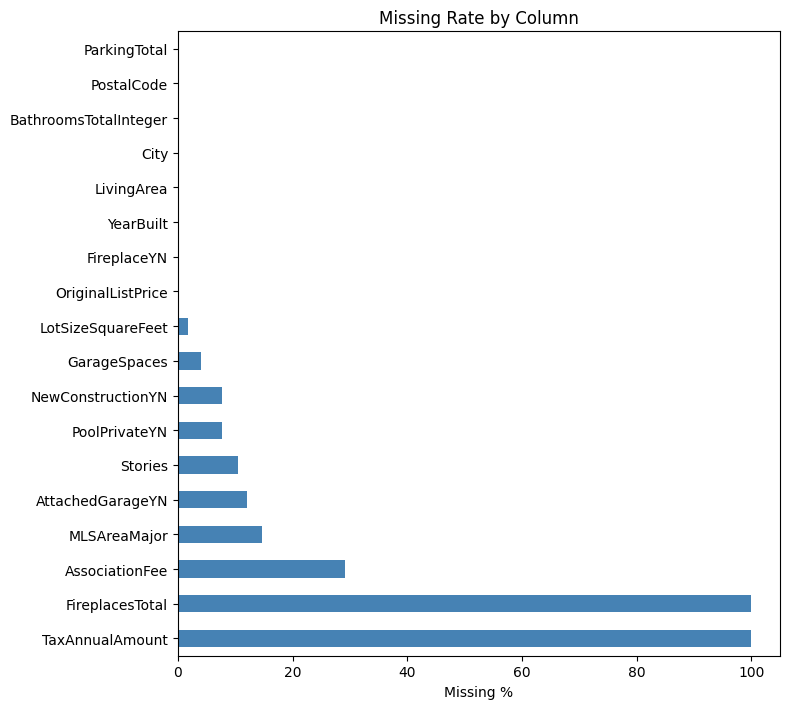

TaxAnnualAmount         100.00
FireplacesTotal         100.00
AssociationFee           29.13
MLSAreaMajor             14.66
AttachedGarageYN         12.11
Stories                  10.40
PoolPrivateYN             7.73
NewConstructionYN         7.63
GarageSpaces              3.96
LotSizeSquareFeet         1.71
OriginalListPrice         0.21
FireplaceYN               0.08
YearBuilt                 0.07
LivingArea                0.05
City                      0.03
BathroomsTotalInteger     0.01
PostalCode                0.00
ParkingTotal              0.00
dtype: float64


In [16]:
cols_of_interest = NUMERIC_COLS + BOOL_COLS + CAT_COLS + [TARGET]
missing = df[cols_of_interest].isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(8, max(4, len(missing) * 0.4)))
missing.plot(kind="barh", color="steelblue")
plt.xlabel("Missing %")
plt.title("Missing Rate by Column")
plt.tight_layout()
plt.show()
print(missing)

### ClosePrice distribution

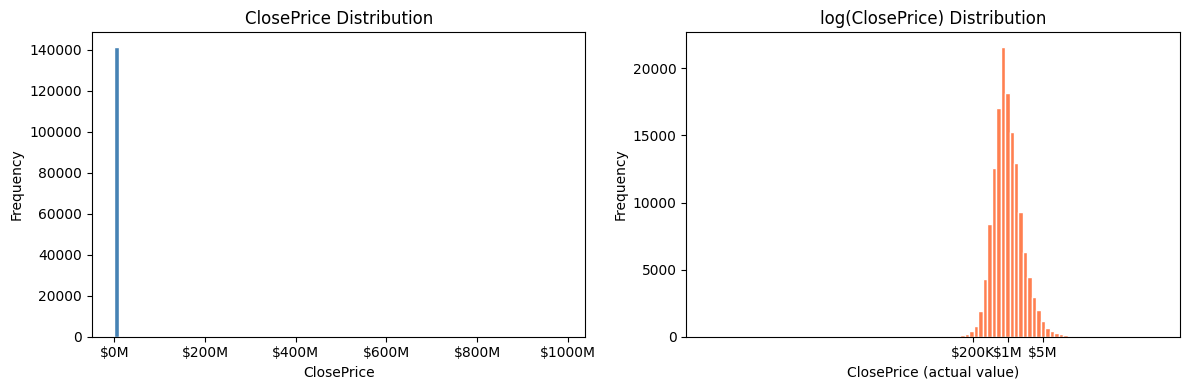

In [17]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[TARGET].plot(kind="hist", bins=100, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("ClosePrice Distribution")
axes[0].set_xlabel("ClosePrice")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x / 1_000_000:.0f}M")
)

np.log1p(df[TARGET]).plot(
    kind="hist", bins=100, ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("log(ClosePrice) Distribution")
axes[1].set_xlabel("ClosePrice (actual value)")
ticks = [np.log1p(v) for v in [200_000, 1_000_000, 5_000_000]]
labels = ["$200K", "$1M", "$5M"]
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


### Outlier check

In [18]:
q1 = df[TARGET].quantile(0.01)
q99 = df[TARGET].quantile(0.99)
print(f"\n1st percentile : ${q1:,.0f}")
print(f"99th percentile: ${q99:,.0f}")
print(f"Records outside 1-99%: {((df[TARGET] < q1) | (df[TARGET] > q99)).sum():,}")



1st percentile : $235,000
99th percentile: $6,400,000
Records outside 1-99%: 2,778


### Correlation with ClosePrice

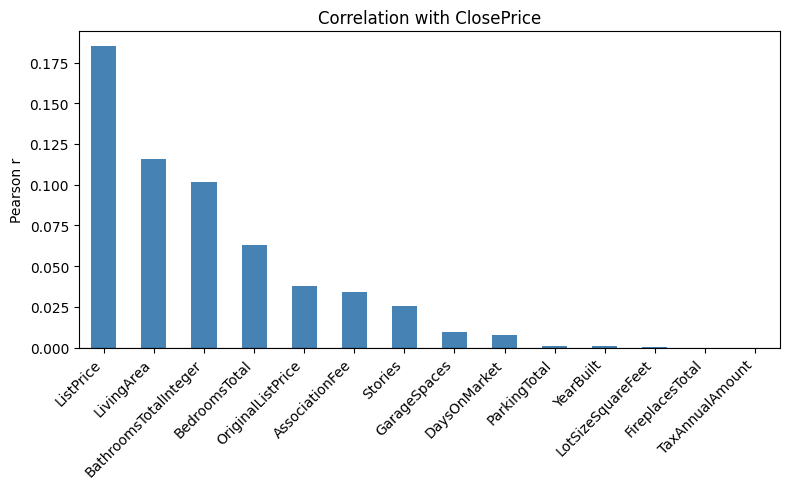

ListPrice               0.18
LivingArea              0.12
BathroomsTotalInteger   0.10
BedroomsTotal           0.06
OriginalListPrice       0.04
AssociationFee          0.03
Stories                 0.03
GarageSpaces            0.01
DaysOnMarket            0.01
ParkingTotal            0.00
YearBuilt               0.00
LotSizeSquareFeet       0.00
FireplacesTotal          NaN
TaxAnnualAmount          NaN
Name: ClosePrice, dtype: float64


In [19]:
corr = (
    df[NUMERIC_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
corr.plot(kind="bar", color=["steelblue" if v > 0 else "coral" for v in corr])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Correlation with ClosePrice")
plt.ylabel("Pearson r")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(corr)


### Monthly median ClosePrice trend

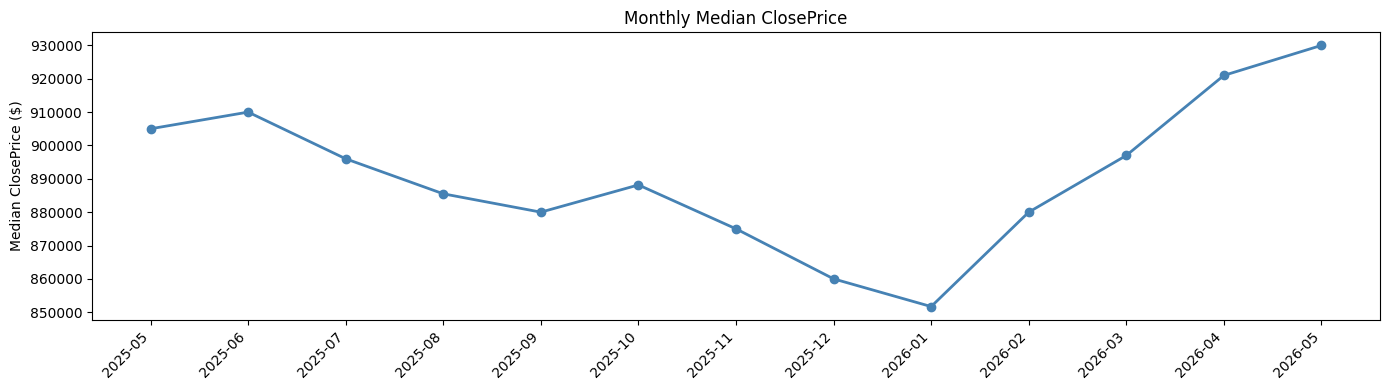

In [20]:
df["YearMonth"] = df["CloseDate"].dt.to_period("M")
monthly = df.groupby("YearMonth")[TARGET].median().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(
    monthly["YearMonth"], monthly[TARGET], marker="o", color="steelblue", linewidth=2
)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Median ClosePrice")
plt.ylabel("Median ClosePrice ($)")
plt.tight_layout()
plt.show()


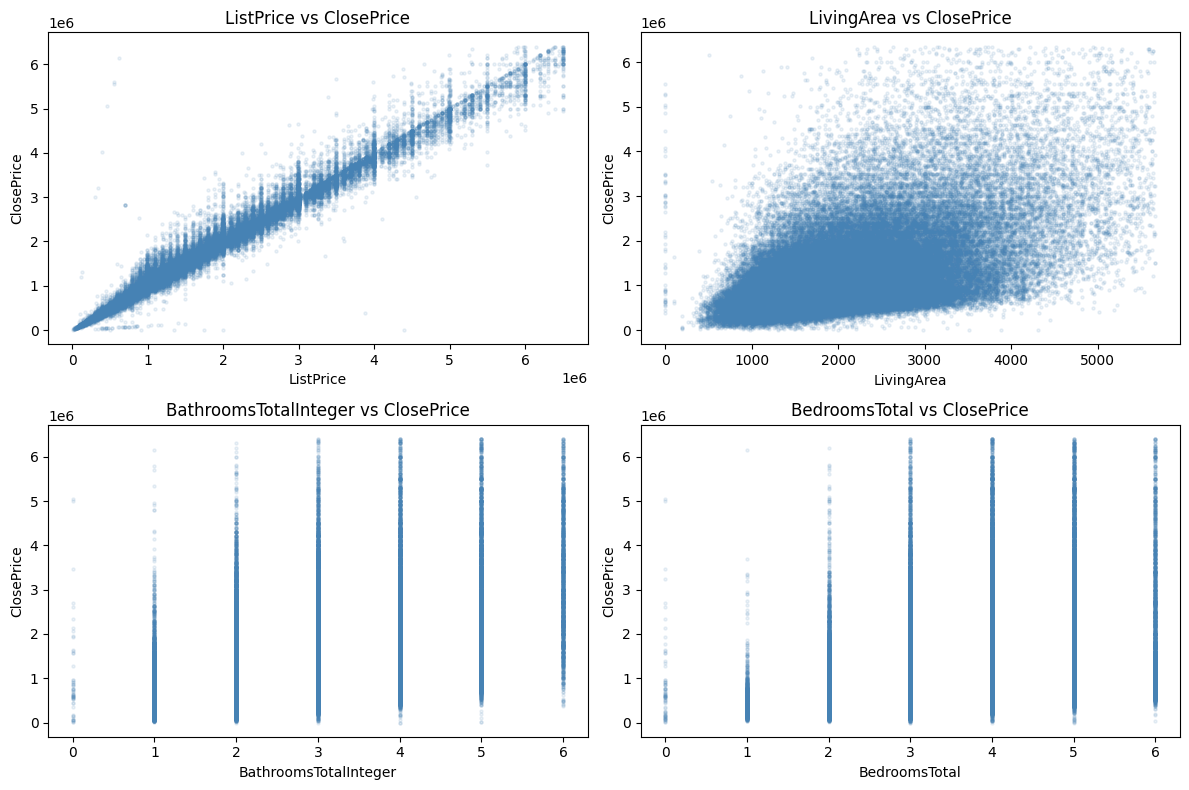

In [ ]:
# ── Cell 9: Scatter plots (top 4 correlated) ─────────────────────────────────
top4 = corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), top4):
    tmp = df[[col, TARGET]].dropna()
    # Cap at 99th percentile for readability
    xp99 = tmp[col].quantile(0.99)
    yp99 = tmp[TARGET].quantile(0.99)
    tmp = tmp[(tmp[col] <= xp99) & (tmp[TARGET] <= yp99)]
    ax.scatter(tmp[col], tmp[TARGET], alpha=0.1, s=5, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("ClosePrice")
    ax.set_title(f"{col} vs ClosePrice")
plt.tight_layout()
plt.show()


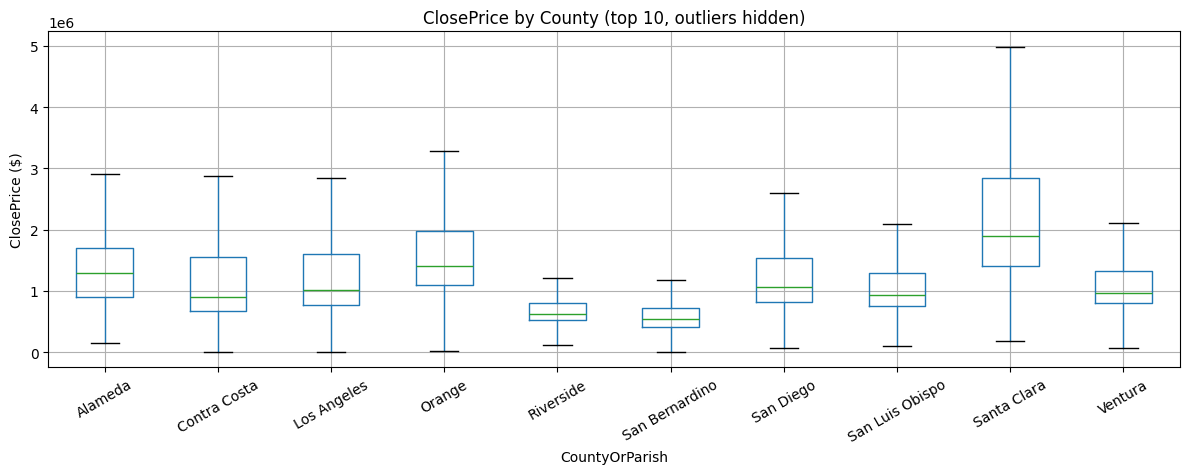

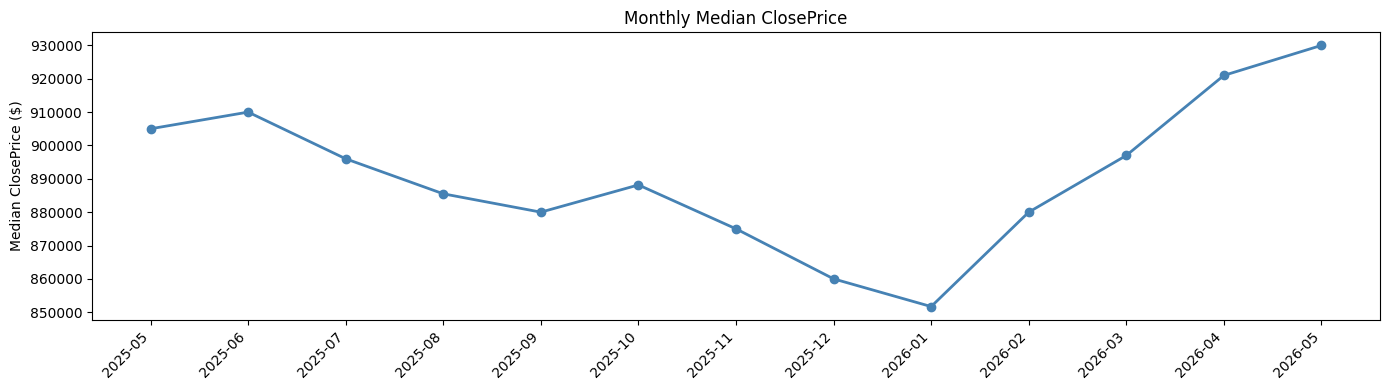

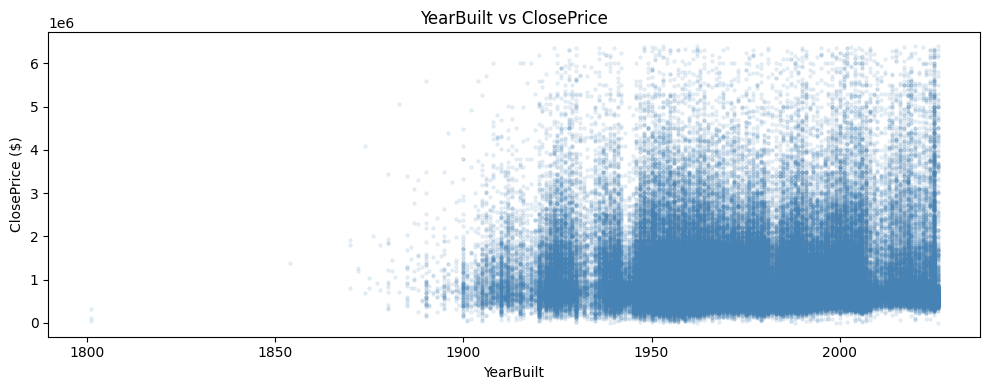

EDA SUMMARY
Total SFR records   : 141,997
Date range          : 2025-05-01 – 2026-05-31
ClosePrice median   : $890,000
ClosePrice mean     : $1,344,654
ClosePrice skewness : 92.609

Top 5 counties by volume:
CountyOrParish
Los Angeles       35440
Riverside         21672
San Diego         15559
San Bernardino    15363
Orange            13658
Name: count, dtype: int64

Features with >30% missing:
FireplacesTotal   1.00
TaxAnnualAmount   1.00
dtype: float64


In [22]:
# ── Cell 10: ClosePrice by County (top 10) ───────────────────────────────────
top_counties = df["CountyOrParish"].value_counts().nlargest(10).index
county_df = df[df["CountyOrParish"].isin(top_counties)]

fig, ax = plt.subplots(figsize=(12, 5))
county_df.boxplot(column=TARGET, by="CountyOrParish", ax=ax, rot=30, showfliers=False)
plt.suptitle("")
ax.set_title("ClosePrice by County (top 10, outliers hidden)")
ax.set_ylabel("ClosePrice ($)")
plt.tight_layout()
plt.show()

# ── Cell 11: Monthly median ClosePrice trend ─────────────────────────────────
df["YearMonth"] = df["CloseDate"].dt.to_period("M")
monthly = df.groupby("YearMonth")[TARGET].median().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(
    monthly["YearMonth"], monthly[TARGET], marker="o", color="steelblue", linewidth=2
)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Median ClosePrice")
plt.ylabel("Median ClosePrice ($)")
plt.tight_layout()
plt.show()

# ── Cell 12: YearBuilt vs ClosePrice ─────────────────────────────────────────
tmp = df[["YearBuilt", TARGET]].dropna()
tmp = tmp[(tmp["YearBuilt"] > 1800) & (tmp["YearBuilt"] <= 2026)]
tmp = tmp[tmp[TARGET] <= tmp[TARGET].quantile(0.99)]

plt.figure(figsize=(10, 4))
plt.scatter(tmp["YearBuilt"], tmp[TARGET], alpha=0.1, s=5, color="steelblue")
plt.xlabel("YearBuilt")
plt.ylabel("ClosePrice ($)")
plt.title("YearBuilt vs ClosePrice")
plt.tight_layout()
plt.show()

# ── Cell 13: EDA Summary ──────────────────────────────────────────────────────
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total SFR records   : {len(df):,}")
print(
    f"Date range          : {df['CloseDate'].min().date()} – {df['CloseDate'].max().date()}"
)
print(f"ClosePrice median   : ${df[TARGET].median():,.0f}")
print(f"ClosePrice mean     : ${df[TARGET].mean():,.0f}")
print(f"ClosePrice skewness : {df[TARGET].skew():.3f}")
print(f"\nTop 5 counties by volume:")
print(df["CountyOrParish"].value_counts().head())
print(f"\nFeatures with >30% missing:")
high_missing = df[cols_of_interest].isna().mean()
print(high_missing[high_missing > 0.3].sort_values(ascending=False))
